In [1]:
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score



%matplotlib inline

1. Загрузите данные из файла abalone.csv.
Это датасет, в котором требуется предсказать возраст ракушки (число колец) по физическим измерениям.

In [2]:
df = pd.read_csv("abalone.csv")
df.head()

,Sex,Length,Diameter,Height,WholeWeight,ShuckedWeight,VisceraWeight,ShellWeight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


2. Преобразуйте признак Sex в числовой.
Значение F должно перейти в -1, I — в 0, M — в 1.

In [4]:
df["Sex"] = df["Sex"].replace({"F": -1, "I": 0, "M": 1})

3. Разделите содержимое файлов на признаки и целевую переменную.
В последнем столбце записана целевая переменная, в остальных — признаки.

In [5]:
X = df.loc[:, "Sex":"ShellWeight"]
y = df["Rings"]

4. Обучите случайный лес (sklearn.ensemble.RandomForestRegressor)
с различным числом деревьев: от 1 до 50 (не забудьте выставить "random_state=1" в конструкторе). Для каждого из вариантов оцените качество работы полученного леса на кросс-валидации по 5 блокам. Используйте параметры "random_state=1" и "shuffle=True" при создании генератора кросс-валидации sklearn.cross_validation.KFold. В качестве меры качества воспользуйтесь коэффициентом детерминации (sklearn.metrics.r2_score).

In [14]:
cv = KFold(n_splits=5, shuffle=True, random_state=1)

scores = [
    cross_val_score(
        RandomForestRegressor(n_estimators=n, random_state=1, n_jobs=-1),
        X, y, cv=cv, scoring='r2'
    ).mean()
    for n in range(1, 51)
]


5. Определите, при каком минимальном количестве деревьев случайный лес показывает качество на кросс-валидации выше 0.52.
Это количество и будет ответом на задание.

In [15]:
for n, score in enumerate(scores):
    if score > 0.52:
        print(n + 1)
        break


21


6. Обратите внимание на изменение качества по мере роста числа деревьев.
Ухудшается ли оно?

<Axes: >

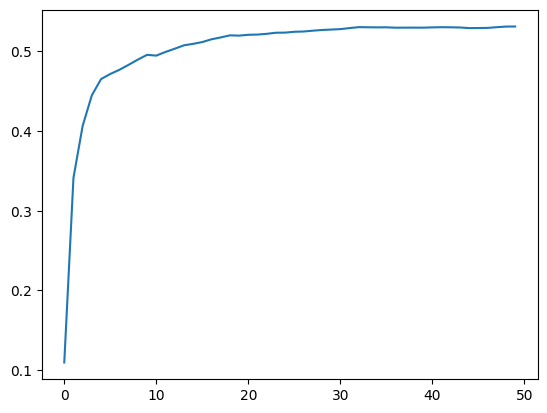

In [13]:
pd.Series(scores).plot()
